In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/2"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第2章 確率 (Probabilities)
## 2.2 確率密度 (Probability Densities)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Bishop & Bishop, 2024) の **第2章 2.2節「確率密度 (Probability Densities)」** を完全網羅し、厳密な理論導出、対話的シミュレーション、および教科書図版（Figure 2.6, 2.7）の忠実な再現を提供するものです。

深層学習において、画像データ、音声信号、分子座標、潜在変数（Latent Variables）、ネットワークの重みなど、多くの対象は **連続空間（Continuous Spaces）** に存在します。
前節（2.1節）で扱った離散変数とは異なり、連続変数では「ある特定の実数値をぴったり観測する確率」は実質的にゼロとなります。そこで、区間や領域に対する確率を正しく定義するために導入されるのが **確率密度 (Probability Density)** です。

---

### 目次
1. [2.2 確率密度の基礎概念 (Probability Densities)](#sec_2_2)
   - 離散から連続への移行の数理
   - 微小区間と確率密度 $p(x)$ (式 2.23)
   - 確率密度の公理：非負性と全空間積分 (式 2.24, 2.25)
   - 累積分布関数 (CDF) $P(x)$ と微積分学の基本定理 (式 2.26, Figure 2.6)
   - 多変量連続分布 $p(\mathbf{x})$ (式 2.27, 2.28)
   - 連続変数における加法定理・乗法定理・ベイズの定理 (式 2.29 - 2.32)
2. [2.2.1 代表的な確率分布 (Example Distributions)](#sec_2_2_1)
   - 不固有分布 (Improper Distribution) と有限正規化
   - 一様分布 (Uniform Distribution) (式 2.33, Figure 2.7)
   - 指数分布 (Exponential Distribution) (式 2.34, Figure 2.7)
   - ラプラス分布 (Laplace Distribution) (式 2.35, Figure 2.7)
   - ディラックのデルタ関数 $\delta(x - \mu)$ (式 2.36)
   - 経験分布 (Empirical Distribution) とデータ表現 (式 2.37)
3. [2.2.2 期待値と共分散 (Expectations and Covariances)](#sec_2_2_2)
   - 離散と連続の期待値 $\mathbb{E}[f]$ (式 2.38, 2.39)
   - モンテカルロ近似 (式 2.40) と大数の法則
   - 多変量および条件付き期待値 (式 2.41, 2.42, 2.43)
   - 分散 $\text{var}[f]$ の定義と代数展開形の厳密導出 (式 2.44, 2.45, 2.46)
   - 共分散 $\text{cov}[x, y]$ の定義と独立性・無相関性の証明 (式 2.47)
   - ベクトル変数の共分散行列 (式 2.48)
4. [まとめと深層学習への接続](#summary)


In [1]:
# 環境セットアップと共通モジュールのインポート
import sys, os
sys.path.append(os.path.abspath('../'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats

from common.plot_utils import setup_style, save_plot
from common.probability import (
    UniformDistribution,
    ExponentialDistribution,
    LaplaceDistribution,
    GaussianMixture1D,
    EmpiricalDistribution,
    monte_carlo_expectation,
    compute_variance,
    compute_covariance,
    compute_covariance_matrix
)

setup_style()
print("環境セットアップ完了: common.probability から Section 2.2 ユーティリティを正常に読み込みました。")


環境セットアップ完了: common.probability から Section 2.2 ユーティリティを正常に読み込みました。


<a id="sec_2_2"></a>
---
## 2.2 確率密度 (Probability Densities)

### 離散変数から連続変数への拡張
2.1節では、コイントスや医療検査結果のような離散的な状態空間上の確率を扱いました。しかし、深層学習の実践では、患者への薬の投与量、物理的センサの連続計測値、画像の連続輝度値、ニューラルネットワークの隠れ層の活性化ベクトルなど、実数空間 $\mathbb{R}$ 上の連続変数をモデル化する必要があります。

連続変数を考える際、直感的に離散確率 $P(X = x)$ をそのまま適用することはできません。なぜなら、連続直線上の任意の1点（例: $x = 0.50000000\dots$）がピンポイントで観測される確率は、無限精度の極限において **厳密に 0** になるからです：
$$P(X = x) = 0 \quad (\forall x \in \mathbb{R})$$

### 確率密度 $p(x)$ の定義
そこで、私たちは「1点での確率」ではなく、「**微小区間 $(x, x + \delta x)$ に変数値が入る確率**」を考えます。
幅 $\delta x \to 0$ の極限において、この確率は微小幅 $\delta x$ に比例すると仮定し、その比例係数として **確率密度 (Probability Density)** $p(x)$ を定義します：

$$p(x \in (x, x + \delta x)) = p(x) \delta x \quad (\delta x \to 0)$$

この定義に基づくと、変数値 $x$ が有限区間 $(a, b)$ の範囲内に収まる確率 $p(x \in (a, b))$ は、微小幅の確率を区間全体で無限に足し合わせること、すなわち **積分 (Integration)** によって求まります：

$$p(x \in (a, b)) = \int_a^b p(x) \, dx \tag{2.23}$$

> **重要な注意点（確率と確率密度の違い）**:
> - 離散確率 $P(X = x)$ は $0 \le P(X = x) \le 1$ を満たさなければなりません。
> - 一方、**確率密度 $p(x)$ は確率そのものではなく「単位長さあたりの確率の割合（密度）」** であるため、**$p(x) > 1$ となることが十分にあり得ます**（後述の一様分布や分散の極小な正規分布など）。


### 確率密度の公理
確率は決して負にならず、かつ変数 $x$ は実数直線上のどこかには必ず存在する（全事象の生起確率は 1）ため、確率密度 $p(x)$ は次の2つの基本条件を満たす必要があります：

$$p(x) \ge 0 \tag{2.24}$$

$$\int_{-\infty}^{\infty} p(x) \, dx = 1 \tag{2.25}$$

### 累積分布関数 (Cumulative Distribution Function: CDF)
確率変数 $x$ が負の無限大からある実数 $z$ までの区間 $(-\infty, z)$ に収まる確率を表す関数を、**累積分布関数 (CDF)** $P(z)$ と呼びます：

$$P(z) = \int_{-\infty}^z p(x) \, dx \tag{2.26}$$

**微積分学の基本定理 (Fundamental Theorem of Calculus)** より、累積分布関数 $P(x)$ を $x$ で微分すると、直ちにその点での確率密度 $p(x)$ が得られます：

$$\frac{d}{dx} P(x) = p(x) \quad \iff \quad P'(x) = p(x)$$

累積分布関数 $P(x)$ は常に単調非減少であり、$\lim_{x \to -\infty} P(x) = 0$、$\lim_{x \to \infty} P(x) = 1$ を満たします。


Figure saved successfully to: result/fig2_06_probability_density_and_cdf.png


Figure saved successfully to: 2/result/fig2_06_probability_density_and_cdf.png


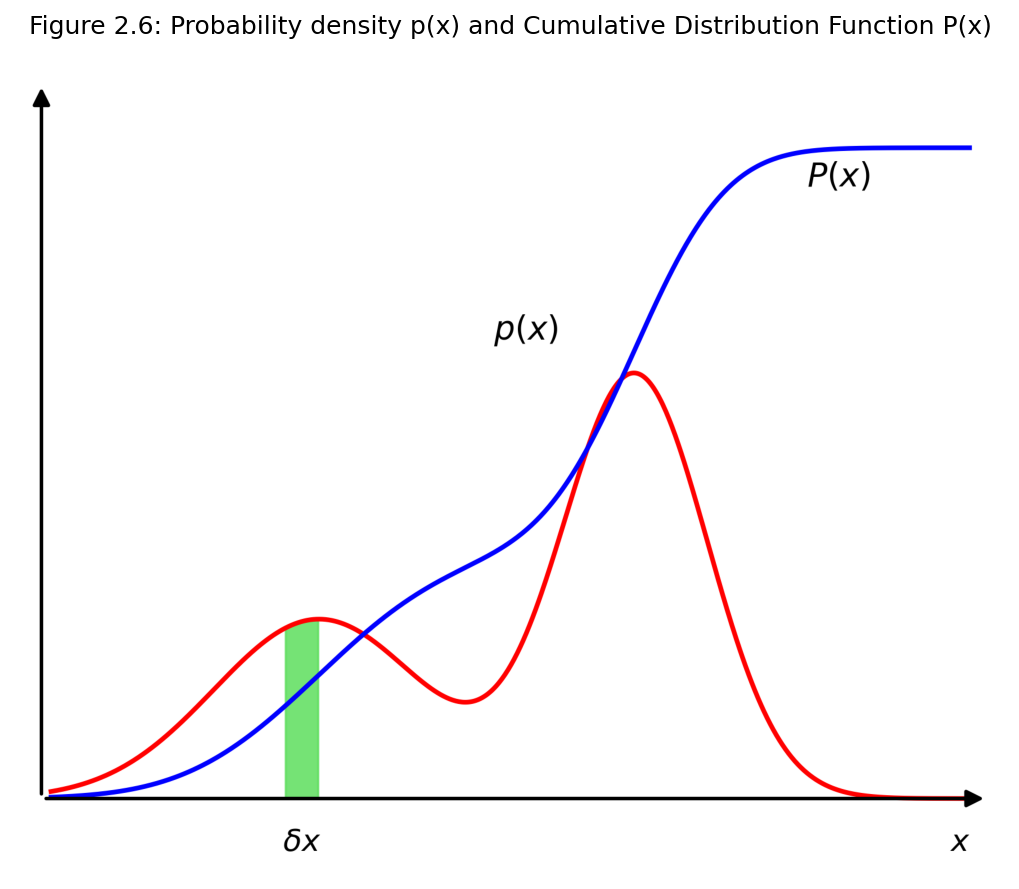

In [2]:
# Figure 2.6: 確率密度 p(x) と累積分布関数 P(x) の可視化
from scripts.generate_ch2_2_figures import generate_figure_2_6

# 図版を生成して保存
generate_figure_2_6(save_dirs=["result", "2/result"])

# 生成した Figure 2.6 をインラインで高解像度表示
img = plt.imread("2/result/fig2_06_probability_density_and_cdf.png")
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
ax.imshow(img)
ax.axis('off')
ax.set_title("Figure 2.6: Probability density p(x) and Cumulative Distribution Function P(x)", fontsize=12, pad=10)
plt.show()


### Figure 2.6 の数理的解説
Figure 2.6 に示されているのは、双峰型（2つの山を持つ）確率密度関数 $p(x)$（赤色の曲線）と、それに対応する累積分布関数 $P(x)$（青色の曲線）です。

1. **微小区間確率と面積**:
   - 緑色で塗られた幅 $\delta x$ の帯の面積は、近似的に $p(x)\delta x$ であり、変数がその微小幅内に落ちる確率を表します。
2. **傾きと密度の対応**:
   - 青色の累積分布関数 $P(x)$ の接線の傾き（微分）が、赤色の確率密度 $p(x)$ の高さに厳密に一致します：$P'(x) = p(x)$。
   - $p(x)$ がピークを迎える領域（$x \approx 1.4$ および $x \approx 3.0$）では、$P(x)$ の傾きが最も急になり、確率が急速に累積していきます。
   - $p(x) \to 0$ となる両端の領域では、$P(x)$ はほぼ平坦（$x \to -\infty$ で $0$、$x \to \infty$ で $1$）になります。


In [3]:
# 数値検証: 微分関係 P'(x) = p(x) の確認
gm = GaussianMixture1D(weights=[0.38, 0.62], means=[1.40, 3.05], stds=[0.55, 0.38])
h = 1e-6
x_eval = np.linspace(0.5, 4.0, 8)

col_diff = "P'(x) (中心差分)"
print(f"{'x':>6} | {'p(x) (理論値)':>14} | {col_diff:>16} | {'絶対誤差':>12}")
print("-" * 55)
for x_val in x_eval:
    exact_pdf = gm.pdf(x_val)
    numerical_deriv = (gm.cdf(x_val + h) - gm.cdf(x_val - h)) / (2 * h)
    error = abs(exact_pdf - numerical_deriv)
    print(f"{x_val:6.2f} | {exact_pdf:14.6f} | {numerical_deriv:16.6f} | {error:12.2e}")
    assert np.isclose(exact_pdf, numerical_deriv, atol=1e-5)

print("\n=> 微分関係 P'(x) = p(x) が全評価点において極めて高精度に成立していることが確認されました。")


     x |     p(x) (理論値) |     P'(x) (中心差分) |         絶対誤差
-------------------------------------------------------
  0.50 |       0.072257 |         0.072257 |     8.13e-12
  1.00 |       0.211581 |         0.211581 |     2.67e-11
  1.50 |       0.271273 |         0.271273 |     3.23e-11
  2.00 |       0.166331 |         0.166331 |     3.21e-11
  2.50 |       0.265664 |         0.265664 |     8.27e-11
  3.00 |       0.649301 |         0.649301 |     1.45e-10
  3.50 |       0.323038 |         0.323038 |     6.15e-11
  4.00 |       0.028603 |         0.028603 |     1.69e-11

=> 微分関係 P'(x) = p(x) が全評価点において極めて高精度に成立していることが確認されました。


### 多変量確率密度と加法定理・乗法定理・ベイズの定理

複数の連続変数 $x_1, \dots, x_D$ をまとめてベクトル $\mathbf{x} = (x_1, \dots, x_D)^T$ で表すとき、多変量確率密度 $p(\mathbf{x}) = p(x_1, \dots, x_D)$ が定義されます。
このとき、点 $\mathbf{x}$ を含む微小体積要素 $\delta \mathbf{x} = \prod_{i=1}^D \delta x_i$ に変数が落ちる確率は $p(\mathbf{x}) \delta \mathbf{x}$ で与えられます。多変量確率密度は以下を満たします：

$$p(\mathbf{x}) \ge 0 \tag{2.27}$$

$$\int p(\mathbf{x}) \, d\mathbf{x} = 1 \tag{2.28}$$

離散確率変数で成立した **加法定理 (Sum Rule)**、**乗法定理 (Product Rule)**、および **ベイズの定理 (Bayes' Theorem)** は、連続変数においても総和記号 $\sum$ を積分記号 $\int$ に置き換えることでそのまま成立します。

#### 1. 連続確率変数の加法定理 (Sum Rule)
同時密度 $p(x, y)$ から不要な変数 $y$ を積分消去（**周辺化 / Marginalization**）することで、周辺密度 $p(x)$ が得られます：

$$p(x) = \int_{-\infty}^{\infty} p(x, y) \, dy \tag{2.29}$$

#### 2. 連続確率変数の乗法定理 (Product Rule)
同時密度 $p(x, y)$ は、条件付き確率密度 $p(y \mid x)$ と周辺確率密度 $p(x)$ の積として厳密に分解されます：

$$p(x, y) = p(y \mid x) p(x) \tag{2.30}$$

#### 3. 連続確率変数のベイズの定理 (Bayes' Theorem)
乗法定理と加法定理を組み合わせることで、条件付き確率の反転関係が導かれます：

$$p(y \mid x) = \frac{p(x \mid y) p(y)}{p(x)} \tag{2.31}$$

ここで、分母の周辺密度（正規化定数 / 証拠 Evidence）は加法定理によって次のように展開されます：

$$p(x) = \int_{-\infty}^{\infty} p(x \mid y) p(y) \, dy \tag{2.32}$$

> **測度論的補足 (Measure-theoretic Perspective)**:
> 厳密な数学において、連続変数に対する加法・乗法定理の証明にはルベーグ積分と測度論（Feller, 1966）が必要です。しかし直感的には、実数軸を微小幅 $\Delta$ の小区間に分割して離散変数とみなし、$\Delta \to 0$ の極限をとることで和が積分へと自然に移行すると理解できます。


<a id="sec_2_2_1"></a>
---
### 2.2.1 代表的な確率分布 (Example Distributions)

連続確率密度には多くの種類が存在し、機械学習や深層学習における基礎的な構成要素として広く利用されています。

#### 1. 不固有分布 (Improper Distribution) と一様分布 (Uniform Distribution)
最も単純な確率密度の候補は「全空間で一定の定数 $p(x) = c$」ですが、実数直線全体 $(-\infty, \infty)$ で積分すると：
$$\int_{-\infty}^{\infty} c \, dx = \infty \quad (c > 0)$$
となり、正規化条件 $\int p(x)dx = 1$ を満たすことができません。このような積分が発散して正規化できない分布を **不固有分布 (Improper Distribution)** と呼びます（無情報事前分布などで形式的に用いられることがあります）。

一方、変数の範囲を有界な有限区間 $(c, d)$（$d > c$）に制限すれば、積分を有限値に収めることができます。これが **一様分布 (Uniform Distribution)** です：

$$p(x) = \frac{1}{d - c} \quad (x \in (c, d)) \tag{2.33}$$

区間外では $p(x) = 0$ です。正規化条件を確認すると：
$$\int_{-\infty}^{\infty} p(x) \, dx = \int_c^d \frac{1}{d - c} \, dx = \frac{d - c}{d - c} = 1$$
となり、確かに正しく正規化されています。


#### 2. 指数分布 (Exponential Distribution)
正の実数 $x \ge 0$ を扱う代表的な分布が **指数分布 (Exponential Distribution)** です。率パラメータ（レート）$\lambda > 0$ を持ち、次式で定義されます：

$$p(x \mid \lambda) = \lambda \exp(-\lambda x) \quad (x \ge 0) \tag{2.34}$$

$x < 0$ では $p(x \mid \lambda) = 0$ です。正規化の確認：
$$\int_0^{\infty} \lambda e^{-\lambda x} \, dx = \left[ -e^{-\lambda x} \right]_0^{\infty} = 0 - (-1) = 1$$
指数分布は、ポアソン過程における事象の発生間隔や、物理・工学における寿命モデルとして頻繁に登場します。

#### 3. ラプラス分布 (Laplace Distribution)
指数分布を両側（実数直線全体）に対称に拡張し、中心を位置パラメータ $\mu$ に移動可能にした分布が **ラプラス分布 (Laplace Distribution)** です。尺度パラメータ $\gamma > 0$ を用いて次式で定義されます：

$$p(x \mid \mu, \gamma) = \frac{1}{2\gamma} \exp\left( -\frac{|x - \mu|}{\gamma} \right) \tag{2.35}$$

正規化の確認（変数変換 $u = (x - \mu)/\gamma$）：
$$\int_{-\infty}^{\infty} \frac{1}{2\gamma} e^{-\frac{|x - \mu|}{\gamma}} \, dx = \frac{1}{2} \int_{-\infty}^{\infty} e^{-|u|} \, du = \int_0^{\infty} e^{-u} \, du = 1$$
ラプラス分布は、平均 $\mu$ において尖った頂点（尖点）を持ち、ガウス分布よりも裾（テイル）が重い特徴があります。機械学習においては、**L1正則化（Lasso回帰）の事前分布** に対応することが知られています。


Figure saved successfully to: result/fig2_07_example_distributions.png
Figure saved successfully to: 2/result/fig2_07_example_distributions.png


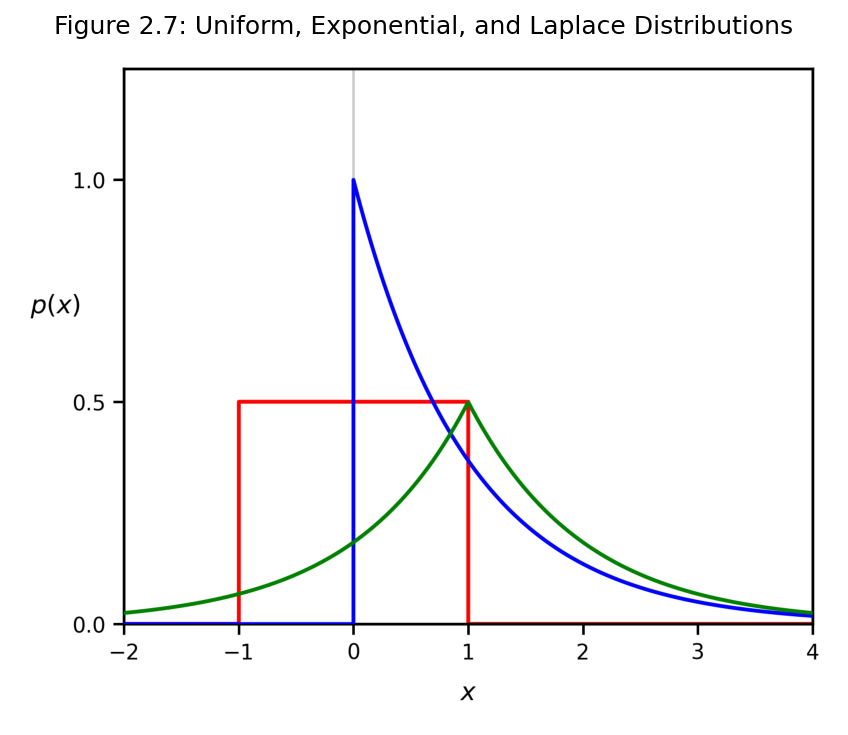

In [4]:
# Figure 2.7: 代表的な連続確率分布の比較プロット
from scripts.generate_ch2_2_figures import generate_figure_2_7

# 図版を生成して保存
generate_figure_2_7(save_dirs=["result", "2/result"])

# 生成した Figure 2.7 をインラインで表示
img7 = plt.imread("2/result/fig2_07_example_distributions.png")
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.imshow(img7)
ax.axis('off')
ax.set_title("Figure 2.7: Uniform, Exponential, and Laplace Distributions", fontsize=12, pad=10)
plt.show()


### Figure 2.7 の比較分析
Figure 2.7 にプロットされた3つの分布の特徴は以下の通りです：

1. **一様分布 (赤線, Uniform on $(-1, 1)$)**:
   - 区間幅 $d - c = 1 - (-1) = 2$ であるため、密度は $p(x) = 1/2 = 0.5$ で一定です。
   - 境界 $x = -1$ および $x = 1$ で不連続に $0$ へと垂直落下します。
2. **指数分布 (青線, Exponential with $\lambda = 1$)**:
   - $x = 0$ において最大値 $p(0) = \lambda = 1.0$ をとり、$x$ の増加に伴って指数関数的に急激に減衰します。
   - $x < 0$ では厳密に $0$ です。
3. **ラプラス分布 (緑線, Laplace with $\mu = 1, \gamma = 1$)**:
   - $\mu = 1$ で対称であり、$x = 1$ で尖点（微分不可能な頂点）を持ち、最大値 $p(1) = 1/(2\gamma) = 0.5$ をとります。
   - ガウス分布と異なり頂点が尖っており、裾野が指数関数的に緩やかに広がっています。


#### 4. ディラックのデルタ関数 (Dirac Delta Function)
もう一つの極めて重要な確率密度が **ディラックのデルタ関数 (Dirac Delta Function)** です：

$$p(x \mid \mu) = \delta(x - \mu) \tag{2.36}$$

デルタ関数は通常の関数ではなく超関数（シュワルツの超関数）であり、次の2つの性質によって定義されます：
1. $x \ne \mu$ のとき $\delta(x - \mu) = 0$
2. 全区間積分が単位面積を持つ：
   $$\int_{-\infty}^{\infty} \delta(x - \mu) \, dx = 1$$

直感的には、「**位置 $\mu$ に集中した、幅が無限小で高さが無限大、かつ全面積が 1 のスパイク**」と見なすことができます。
任意の滑らかな関数 $f(x)$ に対して、デルタ関数との積分は $x = \mu$ での関数値を「抽出（Sifting）」する性質を持ちます：
$$\int_{-\infty}^{\infty} f(x) \delta(x - \mu) \, dx = f(\mu)$$

#### 5. 経験分布 (Empirical Distribution)
有限のデータセット $\mathcal{D} = \{x_1, \dots, x_N\}$ が手元に与えられたとき、デルタ関数を用いて観測データそのものを表現する連続確率密度を構築できます。これを **経験分布 (Empirical Distribution)** と呼びます：

$$p(x \mid \mathcal{D}) = \frac{1}{N} \sum_{n=1}^N \delta(x - x_n) \tag{2.37}$$

各データ点 $x_n$ の位置に面積 $1/N$ のデルタ関数を配置したものであり、全空間で積分すると：
$$\int_{-\infty}^{\infty} p(x \mid \mathcal{D}) \, dx = \frac{1}{N} \sum_{n=1}^N \int_{-\infty}^{\infty} \delta(x - x_n) \, dx = \frac{1}{N} \sum_{n=1}^N 1 = 1$$
となり、正規化条件を満たします。この経験分布は、後述のモンテカルロ近似や経験損失最小化（Empirical Risk Minimization）の基礎となります。


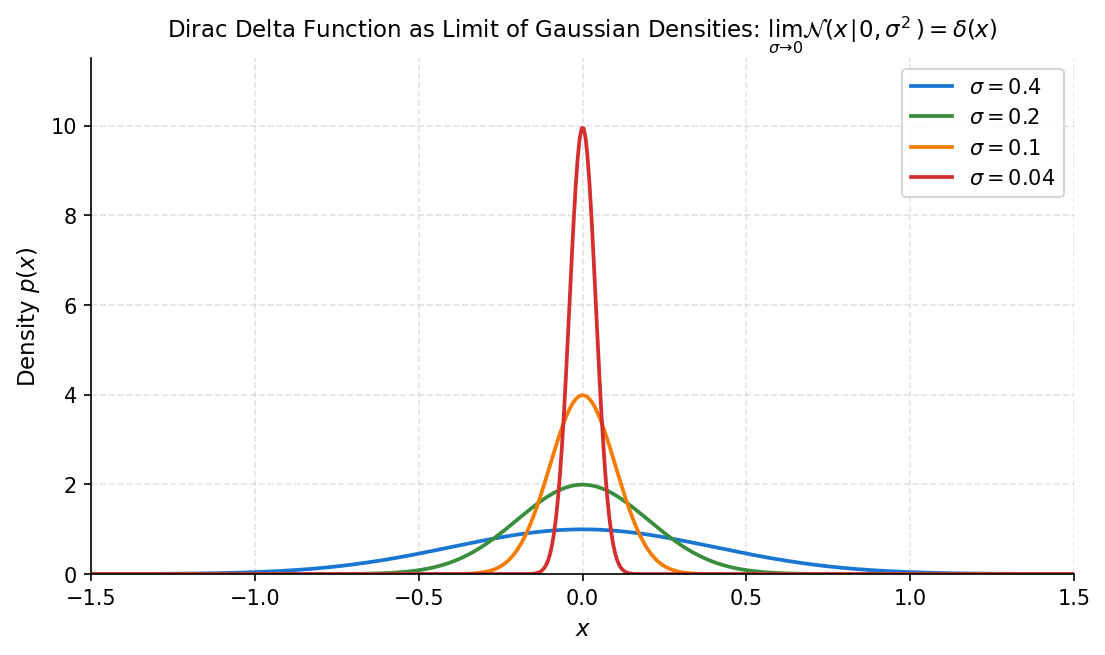

In [5]:
# ディラックのデルタ関数: 分散 sigma -> 0 の正規分布の極限としての可視化
x_grid = np.linspace(-1.5, 1.5, 500)
sigmas = [0.4, 0.2, 0.1, 0.04]
colors = ['#1976d2', '#388e3c', '#f57c00', '#d32f2f']

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=150)

for s, c in zip(sigmas, colors):
    # N(x | 0, sigma^2)
    pdf_spike = (1.0 / (np.sqrt(2 * np.pi) * s)) * np.exp(-0.5 * (x_grid / s)**2)
    ax.plot(x_grid, pdf_spike, label=rf'$\sigma = {s}$', color=c, linewidth=1.8)

ax.set_title(r'Dirac Delta Function as Limit of Gaussian Densities: $\lim_{\sigma \to 0} \mathcal{N}(x \mid 0, \sigma^2) = \delta(x)$', fontsize=11, pad=10)
ax.set_xlabel(r'$x$', fontsize=11)
ax.set_ylabel(r'Density $p(x)$', fontsize=11)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(0, 11.5)
ax.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()


<a id="sec_2_2_2"></a>
---
### 2.2.2 期待値と共分散 (Expectations and Covariances)

確率論において最も基本的かつ頻繁に行われる操作は、**関数の重み付き平均（加重平均）の計算** です。
確率分布 $p(x)$ のもとでのある関数 $f(x)$ の加重平均を $f(x)$ の **期待値 (Expectation)** と呼び、$\mathbb{E}[f]$ と表記します。

#### 1. 離散変数と連続変数の期待値
- **離散確率変数の場合**: 全ての取り得る値に対する重み付きの和：
  $$\mathbb{E}[f] = \sum_x p(x) f(x) \tag{2.38}$$
- **連続確率変数の場合**: 確率密度 $p(x)$ による積分：
  $$\mathbb{E}[f] = \int_{-\infty}^{\infty} p(x) f(x) \, dx \tag{2.39}$$

#### 2. サンプル有限和によるモンテカルロ近似 (Monte Carlo Approximation)
解析的に積分を実行することが困難または不可能な場合でも、分布 $p(x)$ から独立に抽出された有限個（$N$ 個）のサンプル $\{x_1, \dots, x_N\}$ が手に入れば、期待値をサンプル平均として近似できます：

$$\mathbb{E}[f] \simeq \frac{1}{N} \sum_{n=1}^N f(x_n) \tag{2.40}$$

**大数の法則 (Law of Large Numbers)** により、この近似は $N \to \infty$ の極限で真の期待値 $\mathbb{E}[f]$ に確率 1 で収束（一致）します。
なお、式 (2.40) は、経験分布 $p(x \mid \mathcal{D}) = \frac{1}{N}\sum \delta(x - x_n)$ のもとでの期待値の連続積分そのものと解釈できます：
$$\int_{-\infty}^{\infty} p(x \mid \mathcal{D}) f(x) \, dx = \int_{-\infty}^{\infty} \left( \frac{1}{N} \sum_{n=1}^N \delta(x - x_n) \right) f(x) \, dx = \frac{1}{N} \sum_{n=1}^N f(x_n)$$


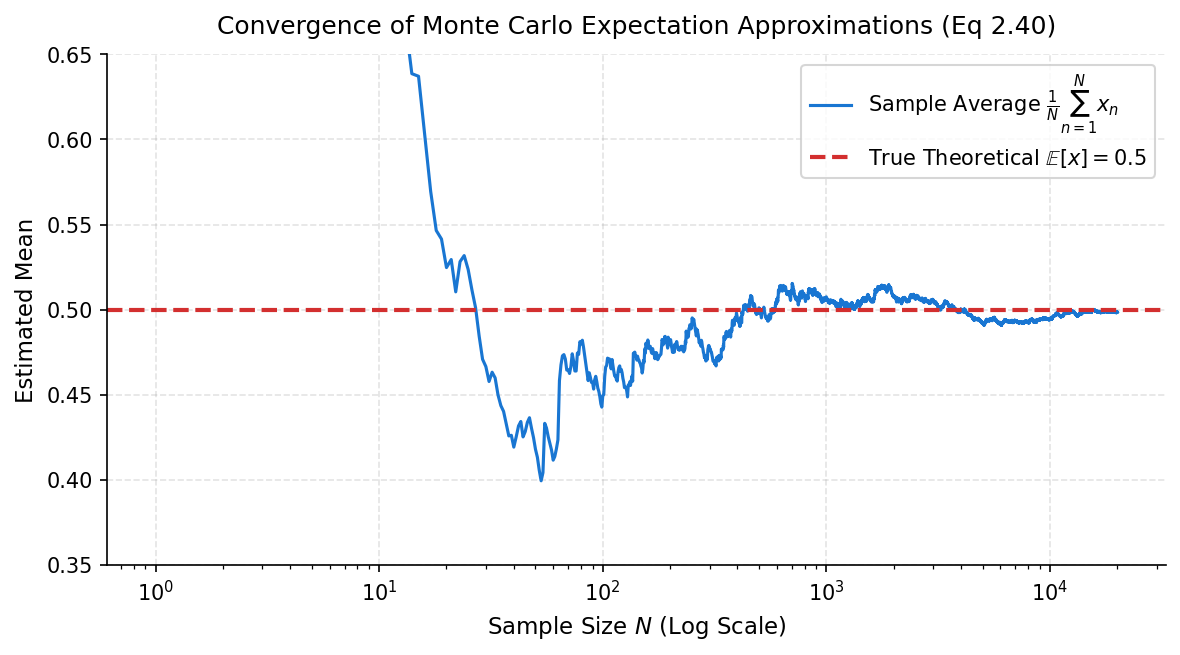

サンプル数 N=100     での推定値: 0.4495 (誤差: 0.0505)
サンプル数 N=1,000   での推定値: 0.5072 (誤差: 0.0072)
サンプル数 N=20,000  での推定値: 0.4986 (誤差: 0.0014)


In [6]:
# モンテカルロ期待値近似の収束検証 (大数の法則)
# 指数分布 Exp(lambda = 2.0) からサンプル抽出: 理論期待値 E[x] = 1/lambda = 0.5
lam_true = 2.0
true_mean = 1.0 / lam_true
e_dist = ExponentialDistribution(lam=lam_true)

N_max = 20000
samples = e_dist.sample(size=N_max, seed=42)
cum_means = np.cumsum(samples) / np.arange(1, N_max + 1)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.plot(np.arange(1, N_max + 1), cum_means, color='#1976d2', linewidth=1.5, label=r'Sample Average $\frac{1}{N}\sum_{n=1}^N x_n$')
ax.axhline(true_mean, color='#d32f2f', linestyle='--', linewidth=2.0, label=rf'True Theoretical $\mathbb{{E}}[x] = {true_mean}$')

ax.set_xscale('log')
ax.set_xlabel(r'Sample Size $N$ (Log Scale)', fontsize=11)
ax.set_ylabel(r'Estimated Mean', fontsize=11)
ax.set_title(r'Convergence of Monte Carlo Expectation Approximations (Eq 2.40)', fontsize=12, pad=10)
ax.set_ylim(0.35, 0.65)
ax.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()

print(f"サンプル数 N=100     での推定値: {cum_means[99]:.4f} (誤差: {abs(cum_means[99]-true_mean):.4f})")
print(f"サンプル数 N=1,000   での推定値: {cum_means[999]:.4f} (誤差: {abs(cum_means[999]-true_mean):.4f})")
print(f"サンプル数 N=20,000  での推定値: {cum_means[-1]:.4f} (誤差: {abs(cum_means[-1]-true_mean):.4f})")


#### 3. 多変量期待値と条件付き期待値
- **多変量関数における特定変数の平均**:
  複数変数の関数 $f(x, y)$ を考えるとき、下付き添字を用いてどの変数について平均をとっているかを明示します：
  $$\mathbb{E}_x[f(x, y)] = \int_{-\infty}^{\infty} p(x) f(x, y) \, dx \tag{2.41}$$
  なお、$x$ について積分消去されているため、$\mathbb{E}_x[f(x, y)]$ は $y$ の関数となります。
- **条件付き期待値 (Conditional Expectation)**:
  条件付き確率分布 $p(x \mid y)$ のもとでの期待値：
  $$\text{離散: } \mathbb{E}_x[f \mid y] = \sum_x p(x \mid y) f(x) \tag{2.42}$$
  $$\text{連続: } \mathbb{E}_x[f \mid y] = \int_{-\infty}^{\infty} p(x \mid y) f(x) \, dx \tag{2.43}$$
  これもまた、与えられた条件 $y$ の関数となります（深層学習の回帰モデルにおいて、最適な予測関数は条件付き期待値 $\mathbb{E}[t \mid \mathbf{x}]$ で与えられます）。


#### 4. 分散 (Variance) の定義と展開式の代数導出
関数 $f(x)$ がその平均値 $\mathbb{E}[f(x)]$ の周りでどれだけばらついているかを表す尺度を **分散 (Variance)** と呼び、次式で定義されます：

$$\text{var}[f] = \mathbb{E}\left[ (f(x) - \mathbb{E}[f(x)])^2 \right] \tag{2.44}$$

ここで、二乗を展開して線形性を適用することにより、分散の有用な計算公式が導かれます：

$$\begin{aligned}
\text{var}[f] &= \mathbb{E}\left[ f(x)^2 - 2 f(x) \mathbb{E}[f(x)] + (\mathbb{E}[f(x)])^2 \right] \\
&= \mathbb{E}[f(x)^2] - 2 \mathbb{E}[f(x)] \mathbb{E}[f(x)] + (\mathbb{E}[f(x)])^2 \\
&= \mathbb{E}[f(x)^2] - (\mathbb{E}[f(x)])^2 \tag{2.45}
\end{aligned}$$

特に関数 $f(x) = x$（変数自身）の分散は次の形になります：

$$\text{var}[x] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 \tag{2.46}$$


#### 5. 共分散 (Covariance) と独立性 (Independence)
2つの確率変数 $x$ と $y$ が互いにどのように連動して変動するかを表す尺度を **共分散 (Covariance)** と呼び、次式で定義されます：

$$\begin{aligned}
\text{cov}[x, y] &= \mathbb{E}_{x,y}\left[ \{x - \mathbb{E}[x]\} \{y - \mathbb{E}[y]\} \right] \\
&= \mathbb{E}_{x,y}\left[ xy - x \mathbb{E}[y] - y \mathbb{E}[x] + \mathbb{E}[x]\mathbb{E}[y] \right] \\
&= \mathbb{E}_{x,y}[xy] - \mathbb{E}[x]\mathbb{E}[y] - \mathbb{E}[y]\mathbb{E}[x] + \mathbb{E}[x]\mathbb{E}[y] \\
&= \mathbb{E}_{x,y}[xy] - \mathbb{E}[x]\mathbb{E}[y] \tag{2.47}
\end{aligned}$$

> **独立性と無相関性の定理**:
> $x$ と $y$ が統計的に独立である場合、同時分布は積に分解されます：$p(x, y) = p(x)p(y)$。このとき、
> $$\mathbb{E}_{x,y}[xy] = \iint xy \, p(x,y) \, dx dy = \left(\int x p(x) dx\right)\left(\int y p(y) dy\right) = \mathbb{E}[x]\mathbb{E}[y]$$
> したがって、**$x$ と $y$ が独立であれば、共分散は厳密に 0** になります：
> $$x, y \text{ が独立} \implies \text{cov}[x, y] = 0$$
> （※逆の「$\text{cov}[x, y] = 0 \implies \text{独立}$」は一般には成り立ちません。共分散は線形な連動性のみを捉えるためです）。

#### 6. ベクトル変数の共分散行列 (Covariance Matrix)
2つのベクトル変数 $\mathbf{x}$ と $\mathbf{y}$ について、共分散は行列として定義されます：

$$\begin{aligned}
\text{cov}[\mathbf{x}, \mathbf{y}] &= \mathbb{E}_{\mathbf{x},\mathbf{y}}\left[ \{\mathbf{x} - \mathbb{E}[\mathbf{x}]\} \{\mathbf{y}^T - \mathbb{E}[\mathbf{y}^T]\} \right] \\
&= \mathbb{E}_{\mathbf{x},\mathbf{y}}[\mathbf{x}\mathbf{y}^T] - \mathbb{E}[\mathbf{x}]\mathbb{E}[\mathbf{y}^T] \tag{2.48}
\end{aligned}$$

ベクトル $\mathbf{x}$ 自身の成分同士の共分散行列は $\text{cov}[\mathbf{x}] \equiv \text{cov}[\mathbf{x}, \mathbf{x}]$ と略記されます。
$\text{cov}[\mathbf{x}]$ は **対称行列（Symmetric）** であり、かつ任意のベクトル $\mathbf{u}$ に対して $\mathbf{u}^T \text{cov}[\mathbf{x}] \mathbf{u} = \text{var}[\mathbf{u}^T \mathbf{x}] \ge 0$ であるため、**半正定値行列（Positive Semi-definite）** となります。


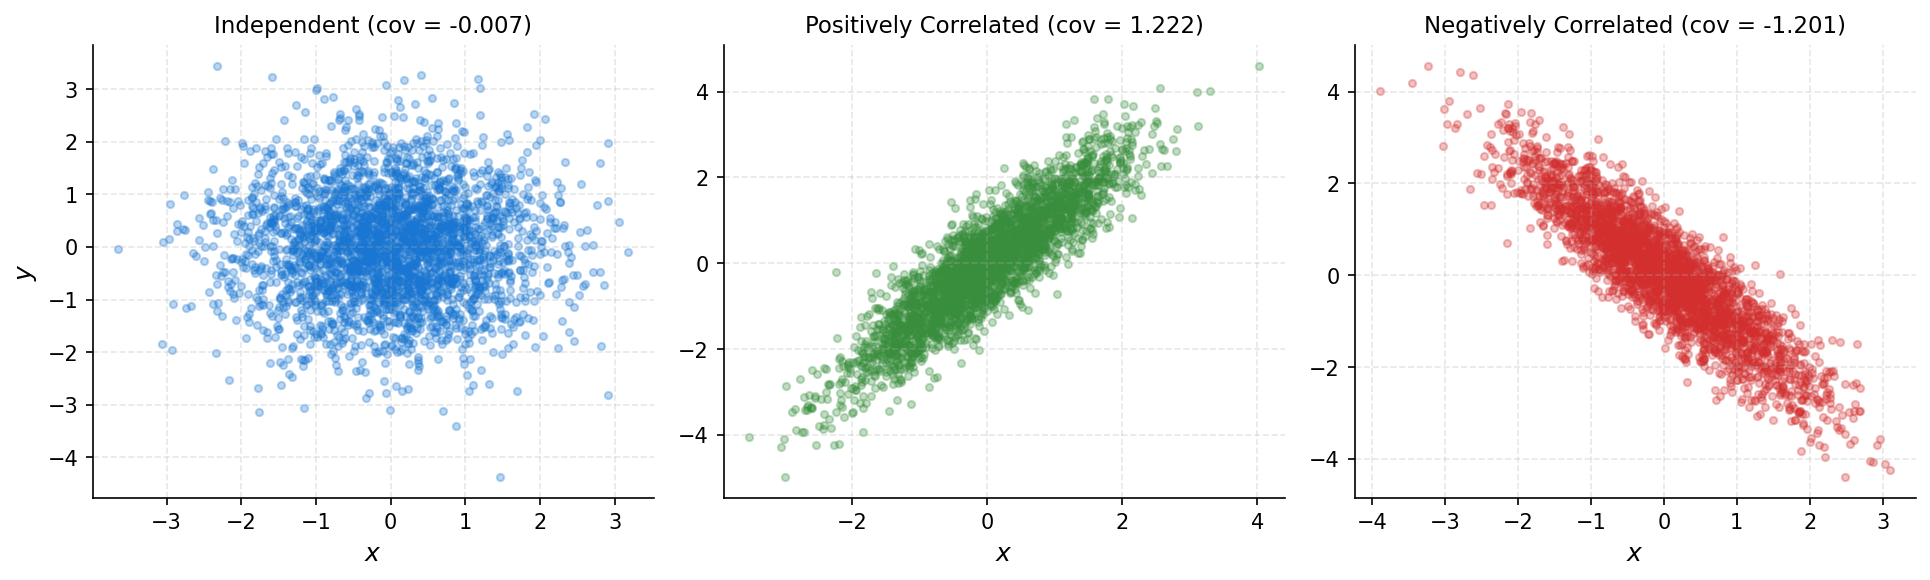

【共分散の数値検証結果】
独立な場合:   E[xy] = -0.0070, E[x]E[y] = -0.0002 => cov = -0.0068 (~ 0)
正の相関:     E[xy] = 1.2218, E[x]E[y] = 0.0001 => cov = 1.2217 (> 0)
負の相関:     E[xy] = -1.2006, E[x]E[y] = -0.0001 => cov = -1.2006 (< 0)


In [7]:
# 統計的独立 vs 相関における共分散の数値シミュレーション
rng = np.random.default_rng(42)
N_samples = 3000

# 1. 独立な変数対 (Independent)
x_indep = rng.normal(loc=0.0, scale=1.0, size=N_samples)
y_indep = rng.normal(loc=0.0, scale=1.0, size=N_samples)
cov_res_indep = compute_covariance(x_indep, y_indep)

# 2. 正の相関を持つ変数対 (Positively correlated)
x_pos = rng.normal(loc=0.0, scale=1.0, size=N_samples)
y_pos = 1.2 * x_pos + rng.normal(loc=0.0, scale=0.6, size=N_samples)
cov_res_pos = compute_covariance(x_pos, y_pos)

# 3. 負の相関を持つ変数対 (Negatively correlated)
x_neg = rng.normal(loc=0.0, scale=1.0, size=N_samples)
y_neg = -1.2 * x_neg + rng.normal(loc=0.0, scale=0.6, size=N_samples)
cov_res_neg = compute_covariance(x_neg, y_neg)

# 可視化
fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=150)

# Independent
axes[0].scatter(x_indep, y_indep, color='#1976d2', alpha=0.3, s=12)
axes[0].set_title(f"Independent (cov = {cov_res_indep['cov']:.3f})", fontsize=11)
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].grid(True, alpha=0.3)

# Positively correlated
axes[1].scatter(x_pos, y_pos, color='#388e3c', alpha=0.3, s=12)
axes[1].set_title(f"Positively Correlated (cov = {cov_res_pos['cov']:.3f})", fontsize=11)
axes[1].set_xlabel(r'$x$')
axes[1].grid(True, alpha=0.3)

# Negatively correlated
axes[2].scatter(x_neg, y_neg, color='#d32f2f', alpha=0.3, s=12)
axes[2].set_title(f"Negatively Correlated (cov = {cov_res_neg['cov']:.3f})", fontsize=11)
axes[2].set_xlabel(r'$x$')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("【共分散の数値検証結果】")
print(f"独立な場合:   E[xy] = {cov_res_indep['E_xy']:.4f}, E[x]E[y] = {cov_res_indep['E_x_E_y']:.4f} => cov = {cov_res_indep['cov']:.4f} (~ 0)")
print(f"正の相関:     E[xy] = {cov_res_pos['E_xy']:.4f}, E[x]E[y] = {cov_res_pos['E_x_E_y']:.4f} => cov = {cov_res_pos['cov']:.4f} (> 0)")
print(f"負の相関:     E[xy] = {cov_res_neg['E_xy']:.4f}, E[x]E[y] = {cov_res_neg['E_x_E_y']:.4f} => cov = {cov_res_neg['cov']:.4f} (< 0)")


In [8]:
# 3次元ベクトル変数の共分散行列 cov[x] の計算と固有値解析 (半正定値性)
true_cov = np.array([
    [2.0, 0.8, 0.2],
    [0.8, 1.5, -0.4],
    [0.2, -0.4, 1.0]
])
mean_vec = np.array([1.0, 2.0, -1.0])
X_vec = rng.multivariate_normal(mean_vec, true_cov, size=20000)

sample_cov_mat = compute_covariance_matrix(X_vec)
eigenvalues = np.linalg.eigvalsh(sample_cov_mat)

print("理論共分散行列:")
print(true_cov)
print("\n推定サンプル共分散行列 (Eq 2.48):")
print(np.round(sample_cov_mat, 3))
print("\n共分散行列の固有値 (すべて >= 0 であり半正定値性を満たす):")
for idx, ev in enumerate(eigenvalues, 1):
    print(f"  固有値 {idx}: {ev:.4f}")

assert np.all(eigenvalues >= 0), "共分散行列は半正定値でなければなりません"


理論共分散行列:
[[ 2.   0.8  0.2]
 [ 0.8  1.5 -0.4]
 [ 0.2 -0.4  1. ]]

推定サンプル共分散行列 (Eq 2.48):
[[ 2.052  0.834  0.188]
 [ 0.834  1.527 -0.405]
 [ 0.188 -0.405  0.985]]

共分散行列の固有値 (すべて >= 0 であり半正定値性を満たす):
  固有値 1: 0.5089
  固有値 2: 1.3859
  固有値 3: 2.6689


<a id="summary"></a>
---
## まとめと深層学習への接続

本節では、連続確率変数に対する確率論の基礎枠組みを体系的に学びました：

1. **確率密度 $p(x)$ と累積分布関数 $P(x)$**:
   - 連続変数では1点での確率は 0 であり、区間確率 $p(x \in (a, b)) = \int_a^b p(x) dx$ として定義。
   - $P'(x) = p(x)$ の微積分学の基本定理（Figure 2.6）。
2. **連続変数の加法定理・乗法定理・ベイズの定理**:
   - 総和記号 $\sum$ が積分記号 $\int$ へと置換されることで、離散変数と完全に同等の確率推論法則が成立。
3. **代表的分布群**:
   - 有限区間の一様分布、正の実数の指数分布、中心と裾野を持つラプラス分布（L1正則化の基礎）、デルタ関数および経験分布（Figure 2.7）。
4. **統計量と数値近似**:
   - 期待値 $\mathbb{E}[f]$、モンテカルロ近似（大数の法則）、分散の展開公式 $\text{var}[f] = \mathbb{E}[f^2] - (\mathbb{E}[f])^2$、共分散と統計的独立性、ベクトルの半正定値共分散行列。

#### 次節（2.3節 ガウス分布）への展望
次節 **2.3節「ガウス分布 (The Gaussian Distribution)」** では、連続確率分布の中で最も中心的な役割を果たす正規分布（Figure 2.8）の数理、平均と分散、最尤推定、最尤推定のバイアス（不偏分散）、および線形回帰との接続について徹底的に探究します。
